# Nome: Davi dos Santos Mattos
## DRE: 119133049

Função Rosenbrock
```
def rosenbrock(X):
  return np.sum(100 * (X[1:] - X[:-1]**2)**2 + (X[:-1] - 1)**2, axis=0)
```

d = {2, 10, 30}


```
Seleção -> Torneio
Recombinação -> Blx
Mutação -> Ceep
Critério de Parada -> Nº Max FE (Chamadas de Função)
```

## Criando Alforítmo Genérico

In [123]:
import numpy as np

def rosenbrock(X):
  """
  Função de Rosenbrock

  X -> Vetor de entrada

  """
  X = np.array(X)
  if X.ndim > 1:
    return np.sum(100 * (X[:, 1:] - X[:, :-1]**2)**2 + (X[:, :-1] - 1)**2, axis=1)
  else:
    return np.sum(100 * (X[1:] - X[:-1]**2)**2 + (X[:-1] - 1)**2, axis=0)

1 - Gerar População Inicial

In [168]:
import numpy as np

SEED_BASE = 72

def criar_populacao(dimensao, num_individuos, intervalo, rng=None):
  """
  Função que cria uma população inicial de indivíduos.

  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão

  """
  if rng is None:
    rng = np.random.default_rng()

  populacao = []
  for i in range(num_individuos):
    individuo = []
    for j in range(dimensao):
      individuo.append(rng.uniform(intervalo[0], intervalo[1]))
    populacao.append(individuo)

  return np.array(populacao)

3- Calcular Aptidão dos Indivíduos

In [169]:
def fitneess(populacao, funcao_avaliacao):
  """
  Retorna a população com a aptidão f(x) de cada indivíduo em uma nova coluna

  populacao -> população de indivíduos
  funcao_avaliacao -> função de avaliação dos indivíduos

  """
  return np.column_stack((populacao, funcao_avaliacao(populacao)))

4 - Seleção por Torneio

In [170]:
def torneio(populacao, funcao_avaliacao, k, rng=None):
  """
  Retorna o melhor indivíduo da população e a nova população sem o melhor indivíduo

  populacao -> população de indivíduos
  funcao_avaliacao -> função de avaliação dos indivíduos
  k -> número de participantes no torneio

  """
  if rng is None:
    rng = np.random.default_rng()
  if populacao.ndim < k:
    individuos = populacao
  else:
    individuos = rng.choice(populacao, size=k, axis=0, replace=False)
  return individuos[np.argmin(individuos[:, -1])] , np.delete(individuos, np.argmin(individuos[:, -1]), axis=0)



5 - Cruzamento BLx

In [171]:
def cruzamento(pais, alpha=0.3, rng=None):

  """
  Realziar o cruzamento entre dois pais utilizando o metodo BLX-alpha

  pais -> lista de dois pais
  alpha -> parâmetro de ajuste do cruzamento

  """
  if rng is None:
    rng = np.random.default_rng()

  filho = []

  for i in range(len(pais[0])-1):
      cmin = np.min(pais[:, i])
      cmax = np.max(pais[:, i])

      intervalo = cmax - cmin

      lower = cmin - alpha * intervalo
      upper = cmax + alpha * intervalo

      gene = rng.uniform(lower, upper)
      filho.append(gene)

  return filho

6- Mutação

In [172]:
def mutacao(individuo, taxa_mutacao=0.05, sigma=0.1, rng=None):
  """
  Realizar a mutação em um indivíduo utilizando a distribuição normal(0,sigma)

  individuo -> indivíduo a ser mutado
  taxa_mutacao -> taxa de mutação
  sigma -> desvio padrão da distribuição normal

  """
  if rng is None:
    rng = np.random.default_rng()

  novo_individuo = individuo.copy()

  for i in range(len(individuo)):
    if rng.random() < taxa_mutacao:
      novo_individuo[i] += rng.normal(0, sigma)

  return novo_individuo

Algoritmo Genético

In [129]:
def algoritmo_genetico(dimensao=2, num_individuos=100, intervalo=[-5,10], parada=50000, seed=None):
  """
  Função que implementa o algoritmo genético


  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão
  parada -> número de chamadas de função para parada

  """

  rng = np.random.default_rng(seed)
  populacao = criar_populacao(dimensao, num_individuos, intervalo, rng=rng)
  chamadas_de_funcao = 0

  populacao = fitneess(populacao, rosenbrock)
  chamadas_de_funcao += populacao.shape[0]
  melhor_individuo = populacao[np.argmin(populacao[:, -1])]


  while(chamadas_de_funcao < parada):
    nova_geracao = []

    while(len(nova_geracao) < len(populacao)):
      pais = []
      for i in range(2):
        pai, _ = torneio(populacao, rosenbrock, 3, rng=rng)
        pais.append(pai)
      pais = np.array(pais)

      filho = cruzamento(pais, rng=rng)
      filho = mutacao(filho, rng=rng)
      nova_geracao.append(filho)

    populacao = np.array(nova_geracao)
    populacao = fitneess(populacao, rosenbrock)
    chamadas_de_funcao += populacao.shape[0]

    if populacao[np.argmin(populacao[:, -1])][-1] <= 1e-2:
      print(f"Melhor individuo: {populacao[np.argmin(populacao[:, -1])]}\t F(x): {populacao[np.argmin(populacao[:, -1])][-1]}\n")
      print(f"Chamadas de Função: {chamadas_de_funcao}\n")
      return populacao
    else:
      melhor_individuo = populacao[np.argmin(populacao[:, -1])]

  print(f"Melhor individuo: {melhor_individuo[:-1]}\t F(x): {melhor_individuo[-1:]}\n")
  return populacao

In [130]:
dois_d = algoritmo_genetico(2, 100, [-5, 10], 100000, seed=SEED_BASE) # Duas dimensões

Melhor individuo: [0.83396466 0.69537348]	 F(x): [0.02756926]



In [131]:
dez_d = algoritmo_genetico(10, 100, [-5,10], 100000, seed=SEED_BASE) # Dez dimensões

Melhor individuo: [0.99914323 0.9982655  0.99715579 0.99448383 0.98912251 0.978954
 0.95908651 0.92043826 0.84720373 0.71773926]	 F(x): [0.03212113]



In [132]:
trinta_d = algoritmo_genetico(30, 100, [-5,10], 100000, seed=SEED_BASE) # Trinta dimensões

Melhor individuo: [ 9.38710840e-01  8.84612020e-01  7.80277196e-01  6.08917908e-01
  3.81838319e-01  1.57986089e-01  3.25691955e-02  1.05903042e-02
  1.00269050e-02  1.02909828e-02  9.78316404e-03  1.01582667e-02
  1.01660610e-02  9.67001063e-03  1.03070897e-02  9.71385112e-03
  1.02981880e-02  9.46489909e-03  9.55938801e-03  9.93458216e-03
  6.47601054e-03  1.04928177e-02  1.00984701e-02  9.86942831e-03
  1.03716401e-02  9.95516045e-03  1.00803952e-02  1.06236703e-02
  9.95046307e-03 -7.02236544e-05]	 F(x): [24.0573221]



## Plotando a populaçao para (1, 2500, 5000, 100000) chamadas de função

In [133]:
def comportamento_algoritmo_genetico(dimensao=2, num_individuos=100, intervalo=[-5,10], parada=50000, seed=None):
  """
  Função que implementa o algoritmo genético


  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão
  parada -> número de chamadas de função para parada

  """

  rng = np.random.default_rng(seed)
  populacao = criar_populacao(dimensao, num_individuos, intervalo, rng=rng)

  populacao = fitneess(populacao, rosenbrock)
  chamadas_de_funcao = num_individuos
  geracoes = {1:populacao}
  #geracoes.append([populacao])
  #print(f"{np.ndim(geracoes)}\n")
  chamadas_de_funcao += populacao.shape[0]
  melhor_individuo = populacao[np.argmin(populacao[:, -1])]


  while(chamadas_de_funcao < parada):
    nova_geracao = []

    while(len(nova_geracao) < len(populacao)):
      pais = []
      for i in range(2):
        pai, _ = torneio(populacao, rosenbrock, 3, rng=rng)
        pais.append(pai)
      pais = np.array(pais)

      filho = cruzamento(pais, rng=rng)
      filho = mutacao(filho, rng=rng)
      nova_geracao.append(filho)

    populacao = np.array(nova_geracao)
    populacao = fitneess(populacao, rosenbrock)
    chamadas_de_funcao += populacao.shape[0]
    if chamadas_de_funcao in [2500, 5000, 100000]:
      #print(f"{chamadas_de_funcao}\n")
      geracoes[chamadas_de_funcao] = populacao

    if populacao[np.argmin(populacao[:, -1])][-1] <= 1e-8:
      print(f"Melhor individuo: {populacao[np.argmin(populacao[:, -1])]}\t F(x): {populacao[np.argmin(populacao[:, -1])][-1]}\n")
      print(f"Chamadas de Função: {chamadas_de_funcao}\n")
      return geracoes
    else:
      melhor_individuo = populacao[np.argmin(populacao[:, -1])]

  print(f"Melhor individuo: {melhor_individuo[:-1]}\t F(x): {melhor_individuo[-1:]}\n")
  return geracoes

In [134]:
comportamento = comportamento_algoritmo_genetico(2, 100, [-5, 10], 100000, seed=SEED_BASE) # Duas dimensões

Melhor individuo: [0.83396466 0.69537348]	 F(x): [0.02756926]



In [135]:
geracao_1 = comportamento[1]
geracao_2500 = comportamento[2500]
geracao_5000 = comportamento[5000]
geracao_100000 = comportamento[100000]

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# Função de Rosenbrock
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def plot_contour(xi,title):

  # Gerando grid para o contour
  x = np.linspace(-6, 11, 100)
  y = np.linspace(-6, 11, 100)
  X, Y = np.meshgrid(x, y)
  Z = rosenbrock(X, Y)

  # pontos (2, 100)
  px = xi[:,0]
  py = xi[:,1]

  # Plot
  plt.figure(figsize=(6, 5))

  # Curvas de nível
  plt.contour(X, Y, Z, levels=30)

  # Pontos por cima
  plt.scatter(px, py, color='red', s=20, label='Pontos')

  # Destaque do mínimo global (1,1)
  plt.scatter(1, 1, color='blue', marker='x', s=80, label='Mínimo')

  plt.legend()
  plt.title(f"{title}")
  plt.xlabel("x")
  plt.ylabel("y")

  plt.show()

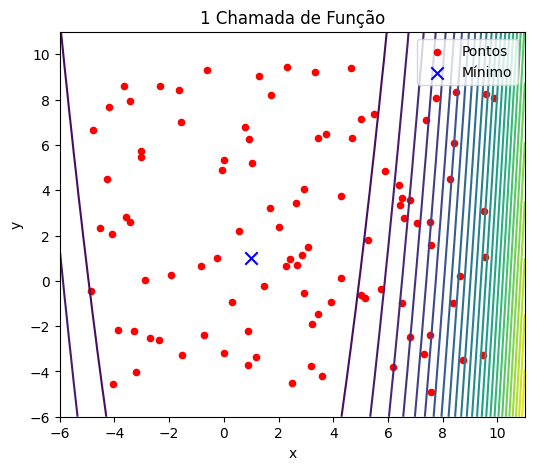

In [137]:
plot_contour(geracao_1, "1 Chamada de Função")

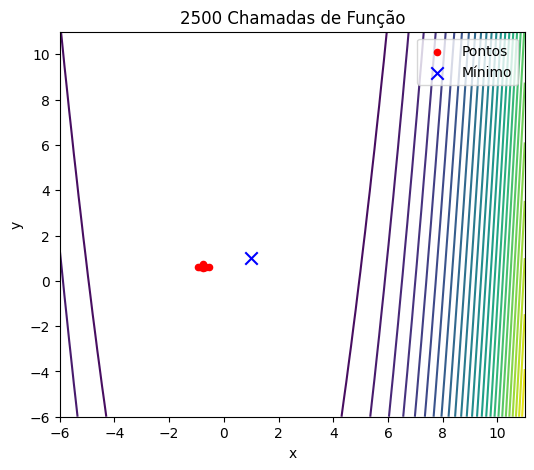

In [138]:
plot_contour(geracao_2500, "2500 Chamadas de Função")

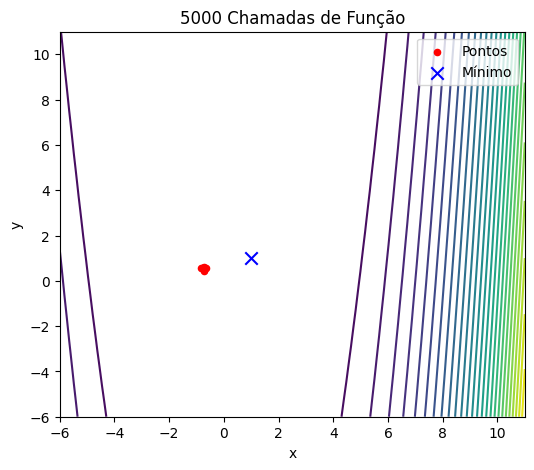

In [139]:
plot_contour(geracao_5000, "5000 Chamadas de Função")

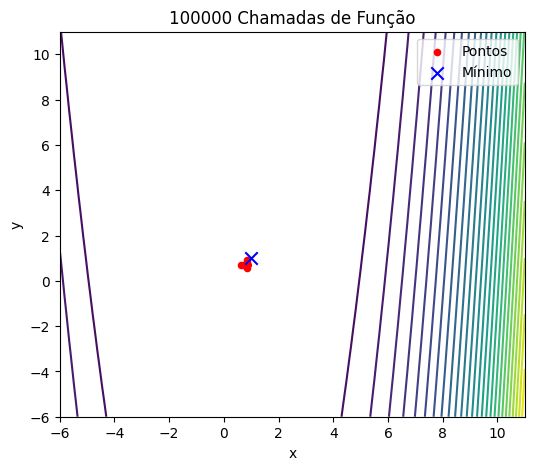

In [140]:
plot_contour(geracao_100000, "100000 Chamadas de Função")

## Utilizando o Pymoo

In [141]:
!pip install -U pymoo

### Configuração padrão do GA no pymoo

Nesta execução, o `GA` é instanciado com a configuração padrão da biblioteca, alterando apenas o tamanho da população e o critério de parada.

Os principais componentes usados por padrão são:

- `sampling = FloatRandomSampling()` para gerar a população inicial com valores reais aleatórios.
- `selection = TournamentSelection(func_comp=comp_by_cv_and_fitness, pressure=2)` para seleção por torneio com pressão 2.
- `crossover = SBX()` para recombinação de variáveis reais via Simulated Binary Crossover.
- `mutation = PM()` para mutação polinomial.
- `survival = FitnessSurvival()` para manter as melhores soluções com base em aptidão e viabilidade.
- `eliminate_duplicates = True` para evitar indivíduos repetidos na população.

Nesta célula, a única alteração em relação ao padrão é `pop_size=100` e `termination=('n_eval', 100000)`, mantendo os demais operadores definidos internamente pelo `pymoo`.

In [142]:
import numpy as np
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.visualization.fitness_landscape import FitnessLandscape

problem = get_problem("rosenbrock", n_var=2)

# ------------------------------------------------------------
# Operadores e parametros utilizados nesta configuracao do GA:
# - pop_size = 100
# - eliminate_duplicates = True
# - sampling = FloatRandomSampling()          (padrao do GA)
# - selection = TournamentSelection(...)      (padrao do GA)
# - crossover = SBX()                         (padrao do GA)
# - mutation = PM()                           (padrao do GA)
# - termination = ('n_eval', 100000)
# ------------------------------------------------------------
algorithm = GA(
    pop_size=100,
    eliminate_duplicates=True,
)

res = minimize(problem,
               algorithm,
               seed=SEED_BASE,
               termination=('n_eval', 100000),
               save_history=True,
               verbose=False)

print(f"Chamadas de Função: {res.algorithm.evaluator.n_eval}\nMelhor Individuo: {res.X}\t F(x): {res.F}")

Chamadas de Função: 100000
Melhor Individuo: [1.0027648  1.00554965]	 F(x): [7.65951692e-06]


In [143]:
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.algorithms.soo.nonconvex.ga import comp_by_cv_and_fitness

algorithm = GA(
    pop_size=100,
    sampling=FloatRandomSampling(),              # população inicial aleatória (real)
    selection=TournamentSelection(func_comp=comp_by_cv_and_fitness, pressure=3),  # torneio com k=3
    crossover=SBX(prob=1.0, eta=15),             # cruzamento (SBX)
    mutation=PM(prob=0.05, eta=20),              # mutação polinomial
    eliminate_duplicates=True
)

res = minimize(
    problem,
    algorithm,
    seed=SEED_BASE,
    termination=("n_eval", 100000),
    save_history=True,
    verbose=False
)

print(f"\nChamadas de Função: {res.algorithm.evaluator.n_eval}")
print(f"Melhor Individuo: {res.X}\tF(x): {res.F}")


Chamadas de Função: 100022
Melhor Individuo: [1.00157434 1.00315902]	F(x): [2.48471944e-06]


In [144]:
# Implementação personalizada dos operadores de seleção, cruzamento e mutação, gerado a partir de IA do ChatGPT, e adaptado para o framework do pymoo. O código é baseado na implementação anterior, mas com as devidas adaptações para funcionar com o pymoo.
import numpy as np
from pymoo.algorithms.soo.nonconvex.ga import GA, comp_by_cv_and_fitness
from pymoo.optimize import minimize
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.core.crossover import Crossover
from pymoo.core.mutation import Mutation

class BLXAlphaCrossover(Crossover):
    def __init__(self, alpha=0.3, seed=None):
        super().__init__(n_parents=2, n_offsprings=1)
        self.alpha = alpha
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, X, **kwargs):
        p1, p2 = X[0], X[1]
        cmin = np.minimum(p1, p2)
        cmax = np.maximum(p1, p2)
        delta = cmax - cmin

        lower = cmin - self.alpha * delta
        upper = cmax + self.alpha * delta

        U = self.rng.random(size=lower.shape)
        off = lower + U * (upper - lower)

        if problem.xl is not None and problem.xu is not None:
            off = np.clip(off, problem.xl, problem.xu)

        return off[None, :, :]

class CreepMutation(Mutation):
    def __init__(self, prob=0.05, sigma=0.1, seed=None):
        super().__init__()
        self.prob = prob
        self.sigma = sigma
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, X, **kwargs):
        Y = X.copy()
        mask = self.rng.random(size=Y.shape) < self.prob
        Y[mask] += self.rng.normal(0.0, self.sigma, size=int(mask.sum()))

        if problem.xl is not None and problem.xu is not None:
            Y = np.clip(Y, problem.xl, problem.xu)

        return Y

algorithm = GA(
    pop_size=100,
    selection=TournamentSelection(func_comp=comp_by_cv_and_fitness, pressure=3),  # seleção por torneio
    crossover=BLXAlphaCrossover(alpha=0.3, seed=SEED_BASE),                                     # recombinação BLX-α
    mutation=CreepMutation(prob=0.05, sigma=0.1, seed=SEED_BASE),                               # mutação creep
    eliminate_duplicates=True,
    )

res = minimize(
    problem,
    algorithm,
    seed=SEED_BASE,
    termination=("n_eval", 100000),
    save_history=True,
    verbose=False,
    )

print(f"\nChamadas de Função: {res.algorithm.evaluator.n_eval}")
print(f"Melhor Individuo: {res.X}\tF(x): {res.F}")


Chamadas de Função: 100080
Melhor Individuo: [1.01135777 1.02290069]	F(x): [0.00012931]


## Comparação entre os GA e gráfico da curva de convergência média

### GA Implementado

In [173]:
import numpy as np

def rosenbrock(X):
    X = np.array(X)
    if X.ndim > 1:
        return np.sum(100 * (X[:, 1:] - X[:, :-1] ** 2) ** 2 + (X[:, :-1] - 1) ** 2, axis=1)
    return np.sum(100 * (X[1:] - X[:-1] ** 2) ** 2 + (X[:-1] - 1) ** 2, axis=0)

def ga_manual(dimensao=2, num_individuos=100, intervalo=[-5,10], parada=50000, seed=None):
  """
  Função que implementa o algoritmo genético


  dimensao -> número de dimensões do problema
  n_individuos -> número de indivíduos na população
  intervalo -> intervalo de valores possíveis para cada dimensão
  parada -> número de chamadas de função para parada

  """
  rng = np.random.default_rng(seed)

  populacao = criar_populacao(dimensao, num_individuos, intervalo, rng=rng)
  chamadas_de_funcao = 0

  populacao = fitneess(populacao, rosenbrock)
  chamadas_de_funcao += populacao.shape[0]
  melhor_individuo = populacao[np.argmin(populacao[:, -1])]
  historico = [float(np.min(populacao[:, -1]))]

  while(chamadas_de_funcao < parada):
    nova_geracao = []

    while(len(nova_geracao) < len(populacao)):
      pais = []
      for i in range(2):
        pai, _ = torneio(populacao, rosenbrock, 3, rng=rng)
        pais.append(pai)
      pais = np.array(pais)

      filho = cruzamento(pais, rng=rng)
      filho = mutacao(filho, rng=rng)
      nova_geracao.append(filho)

    populacao = np.array(nova_geracao)
    populacao = fitneess(populacao, rosenbrock)
    chamadas_de_funcao += populacao.shape[0]
    historico.append(float(np.min(populacao[:, -1])))
  return np.array(historico)

### GA pymoo

In [174]:
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize
from pymoo.problems import get_problem

def ga_pymoo(dimensao=2, num_individuos=100, parada=100000, seed=None):
    problema = get_problem("rosenbrock", n_var=dimensao)
    algorithm = GA(
        pop_size=num_individuos,
        eliminate_duplicates=True,
    )

    res = minimize(
        problema,
        algorithm,
        seed=seed,
        termination=("n_eval", parada),
        save_history=True,
        verbose=False,
    )

    historico = [float(np.min(algo.pop.get("F"))) for algo in res.history]
    return np.array(historico)

### GA pymoo configurado como o implementado

In [175]:
import numpy as np
from pymoo.algorithms.soo.nonconvex.ga import GA, comp_by_cv_and_fitness
from pymoo.optimize import minimize
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.core.crossover import Crossover
from pymoo.core.mutation import Mutation

class BLXAlphaCrossover(Crossover):
    def __init__(self, alpha=0.3, seed=None):
        super().__init__(n_parents=2, n_offsprings=1)
        self.alpha = alpha
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, X, **kwargs):
        p1, p2 = X[0], X[1]
        cmin = np.minimum(p1, p2)
        cmax = np.maximum(p1, p2)
        delta = cmax - cmin

        lower = cmin - self.alpha * delta
        upper = cmax + self.alpha * delta

        U = self.rng.random(size=lower.shape)
        off = lower + U * (upper - lower)

        if problem.xl is not None and problem.xu is not None:
            off = np.clip(off, problem.xl, problem.xu)

        return off[None, :, :]

class CreepMutation(Mutation):
    def __init__(self, prob=0.05, sigma=0.1, seed=None):
        super().__init__()
        self.prob = prob
        self.sigma = sigma
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, X, **kwargs):
        Y = X.copy()
        mask = self.rng.random(size=Y.shape) < self.prob
        Y[mask] += self.rng.normal(0.0, self.sigma, size=int(mask.sum()))

        if problem.xl is not None and problem.xu is not None:
            Y = np.clip(Y, problem.xl, problem.xu)

        return Y

def ga_pymoo_configurado(dimensao=2, num_individuos=100, parada=100000, seed=None):
    problema = get_problem("rosenbrock", n_var=dimensao)

    algorithm = GA(
        pop_size=num_individuos,
        selection=TournamentSelection(func_comp=comp_by_cv_and_fitness, pressure=3),  # seleção por torneio
        crossover=BLXAlphaCrossover(alpha=0.3, seed=seed),                                     # recombinação BLX-α
        mutation=CreepMutation(prob=0.05, sigma=0.1, seed=seed),                               # mutação creep
        eliminate_duplicates=True,
    )

    res = minimize(
        problema,
        algorithm,
        seed=seed,
        termination=("n_eval", parada),
        save_history=True,
        verbose=False,
    )

    historico = [float(np.min(algo.pop.get("F"))) for algo in res.history]
    return np.array(historico)

## 2D (Implementado + pymoo padrão + pymoo configurado)

In [176]:
n_execucoes = 30
dimensao = 2
num_individuos = 100
parada = 100000

1/30
2/30
3/30
4/30
5/30
6/30
7/30
8/30
9/30
10/30
11/30
12/30
13/30
14/30
15/30
16/30
17/30
18/30
19/30
20/30
21/30
22/30
23/30
24/30
25/30
26/30
27/30
28/30
29/30
30/30


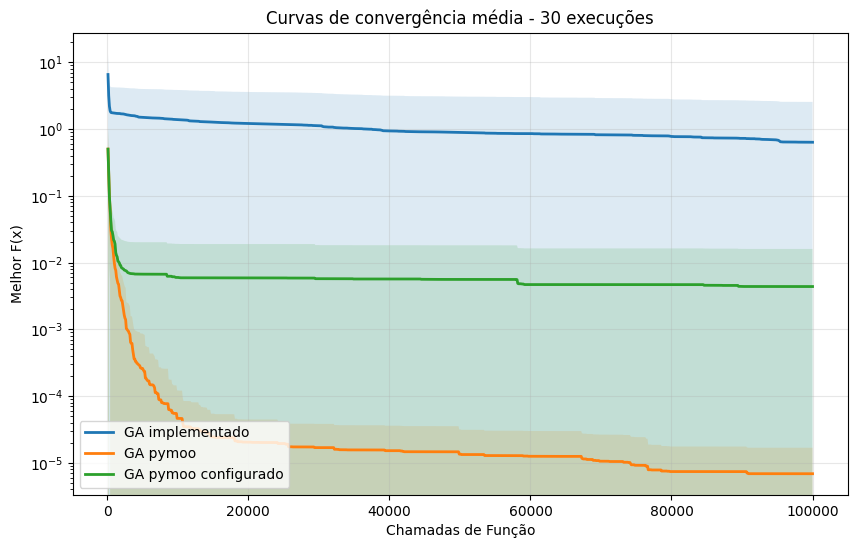

In [177]:
import matplotlib.pyplot as plt

historicos_manual = []
historicos_pymoo_configurado = []
historicos_pymoo = []

for execucao in range(n_execucoes):
    print(f"{execucao + 1}/{n_execucoes}")
    seed_execucao = SEED_BASE + execucao
    historicos_manual.append(ga_manual(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo.append(ga_pymoo(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo_configurado.append(ga_pymoo_configurado(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))

min_len = min(min(len(h) for h in historicos_manual), min(len(h) for h in historicos_pymoo), min(len(h) for h in historicos_pymoo_configurado))

manual_array = np.array([h[:min_len] for h in historicos_manual])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo])
pymoo_configurado_array = np.array([h[:min_len] for h in historicos_pymoo_configurado])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
media_pymoo_configurado = pymoo_configurado_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)
desvio_pymoo_configurado = pymoo_configurado_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.plot(eixo, media_pymoo_configurado, label="GA pymoo configurado", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.fill_between(eixo, media_pymoo_configurado - desvio_pymoo_configurado, media_pymoo_configurado + desvio_pymoo_configurado, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Descrição da tabela

A tabela abaixo resume as 30 execuções de cada versão do algoritmo. As colunas significam:

- `Versão`: nome da implementação avaliada.
- `Fitness final médio`: média do melhor fitness obtido ao final das 30 execuções.
- `Desvio padrão final`: dispersão dos valores finais de fitness entre as 30 execuções.
- `Mediana do fitness final`: valor central da distribuição dos fitness finais.
- `Execução mediana`: execução cujo fitness final ficou mais próximo da mediana.
- `Fitness da execução mediana`: fitness final dessa execução representativa.

In [183]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual),
    resumo_final_execucoes("GA pymoo", historicos_pymoo),
    resumo_final_execucoes("GA pymoo configurado", historicos_pymoo_configurado),
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo = tabela_resumo[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo)

melhor_media = tabela_resumo.loc[tabela_resumo["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo.loc[tabela_resumo["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)


Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,13.6985,25.5053,5.23377,16,5.24958
1,GA pymoo,5.57747,1.92067,6.05638,30,6.05737
2,GA pymoo configurado,7.19376,0.281863,7.28029,21,7.27686



Conclusão: Melhor média: GA pymoo, 
Melhor mediana: GA implementado.



## 2D (Implementado + pymoo padrão)

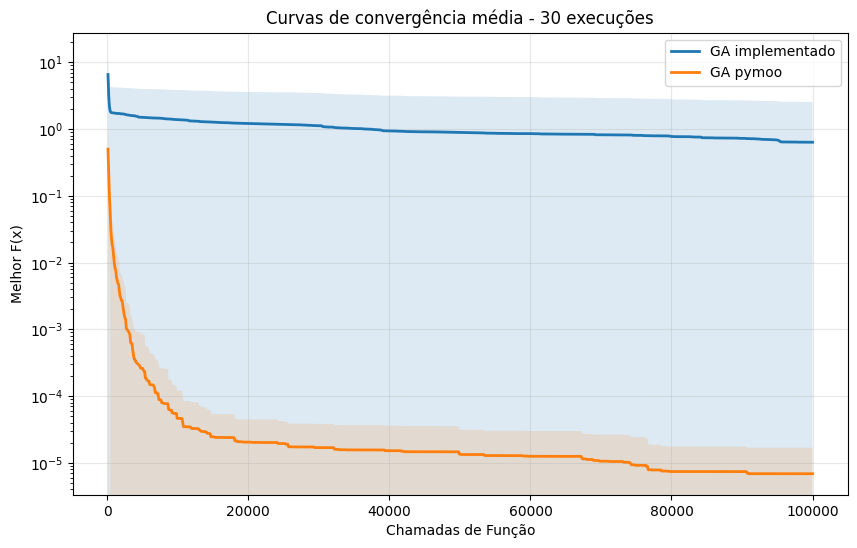

In [151]:
import matplotlib.pyplot as plt

min_len = min(min(len(h) for h in historicos_manual), min(len(h) for h in historicos_pymoo))

manual_array = np.array([h[:min_len] for h in historicos_manual])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Descrição da tabela

Dicionário textual da tabela:

- `Versão`: implementação avaliada no comparativo.
- `Fitness final médio`: média dos melhores fitness finais das 30 execuções.
- `Desvio padrão final`: variabilidade dos fitness finais entre as 30 execuções.
- `Mediana do fitness final`: valor mediano dos fitness finais.
- `Execução mediana`: execução mais próxima da mediana.
- `Fitness da execução mediana`: fitness final da execução mediana.

In [ ]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo_2v = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual),
    resumo_final_execucoes("GA pymoo", historicos_pymoo),
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo_2v = tabela_resumo_2v[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo_2v)

melhor_media = tabela_resumo_2v.loc[tabela_resumo_2v["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo_2v.loc[tabela_resumo_2v["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)

Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,13.6985,25.5053,5.23377,16,5.24958
1,GA pymoo,5.57747,1.92067,6.05638,30,6.05737



Conclusão: Melhor média: GA pymoo, 
Melhor mediana: GA implementado.



## Testando para diferente dimensões

### 5D (Implementado + pymoo padrão + pymoo configurado)

In [202]:
n_execucoes = 30
dimensao = 5
num_individuos = 100
parada = 100000

In [203]:
import matplotlib.pyplot as plt

historicos_manual_5d = []
historicos_pymoo_configurado_5d = []
historicos_pymoo_5d = []

for execucao in range(n_execucoes):
    print(f"{execucao + 1}/{n_execucoes}")
    seed_execucao = SEED_BASE + execucao
    historicos_manual_5d.append(ga_manual(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo_5d.append(ga_pymoo(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo_configurado_5d.append(ga_pymoo_configurado(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))

1/30
2/30
3/30
4/30
5/30
6/30
7/30
8/30
9/30
10/30
11/30
12/30
13/30
14/30
15/30
16/30
17/30
18/30
19/30
20/30
21/30
22/30
23/30
24/30
25/30
26/30
27/30
28/30
29/30
30/30


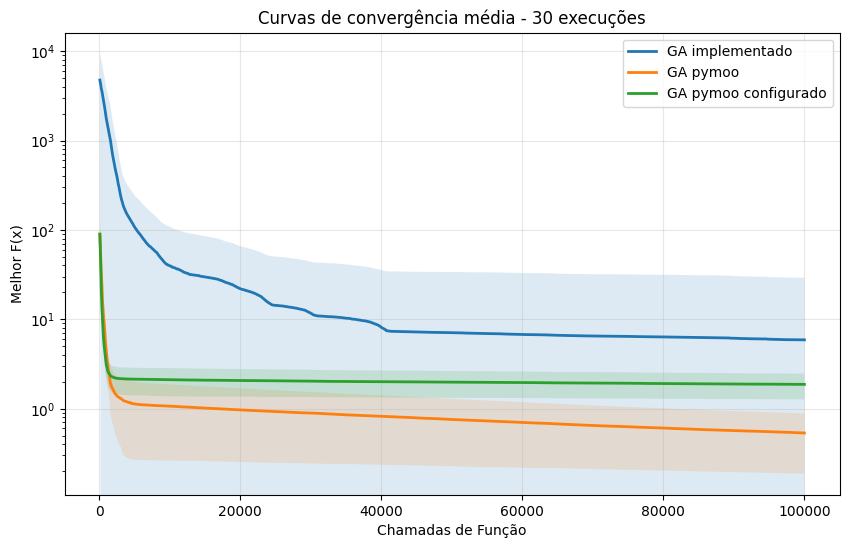

In [204]:
min_len = min(min(len(h) for h in historicos_manual_5d), min(len(h) for h in historicos_pymoo_5d), min(len(h) for h in historicos_pymoo_configurado_5d))

manual_array = np.array([h[:min_len] for h in historicos_manual_5d])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo_5d])
pymoo_configurado_array = np.array([h[:min_len] for h in historicos_pymoo_configurado_5d])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
media_pymoo_configurado = pymoo_configurado_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)
desvio_pymoo_configurado = pymoo_configurado_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.plot(eixo, media_pymoo_configurado, label="GA pymoo configurado", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.fill_between(eixo, media_pymoo_configurado - desvio_pymoo_configurado, media_pymoo_configurado + desvio_pymoo_configurado, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual_5d),
    resumo_final_execucoes("GA pymoo", historicos_pymoo_5d),
    resumo_final_execucoes("GA pymoo configurado", historicos_pymoo_configurado_5d),
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo = tabela_resumo[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo)

melhor_media = tabela_resumo.loc[tabela_resumo["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo.loc[tabela_resumo["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)


Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,5.88677,23.3532,0.712228,7,0.685854
1,GA pymoo,0.533806,0.346973,0.657363,9,0.620673
2,GA pymoo configurado,1.86835,0.597288,1.98421,8,1.9609



Conclusão: Melhor média: GA pymoo, 
Melhor mediana: GA pymoo.



### 5D (Implementado + pymoo padrão)

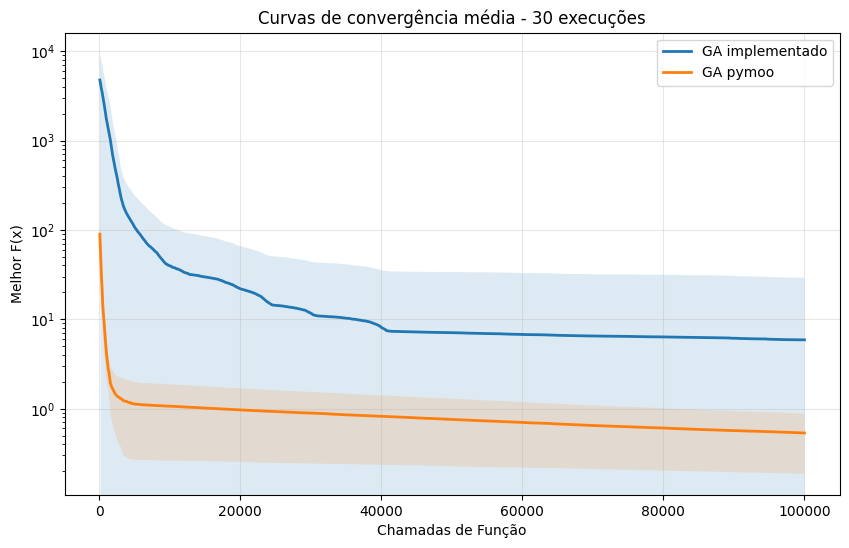

In [206]:
import matplotlib.pyplot as plt
min_len = min(min(len(h) for h in historicos_manual_5d), min(len(h) for h in historicos_pymoo_5d))

manual_array = np.array([h[:min_len] for h in historicos_manual_5d])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo_5d])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### Descrição da tabela

Dicionário textual da tabela:

- `Versão`: implementação avaliada no comparativo.
- `Fitness final médio`: média dos melhores fitness finais das 30 execuções.
- `Desvio padrão final`: variabilidade dos fitness finais entre as 30 execuções.
- `Mediana do fitness final`: valor mediano dos fitness finais.
- `Execução mediana`: execução mais próxima da mediana.
- `Fitness da execução mediana`: fitness final da execução mediana.

In [207]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo_2v = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual_5d),
    resumo_final_execucoes("GA pymoo", historicos_pymoo_5d)
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo_2v = tabela_resumo_2v[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo_2v)

melhor_media = tabela_resumo_2v.loc[tabela_resumo_2v["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo_2v.loc[tabela_resumo_2v["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)

Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,5.88677,23.3532,0.712228,7,0.685854
1,GA pymoo,0.533806,0.346973,0.657363,9,0.620673



Conclusão: Melhor média: GA pymoo, 
Melhor mediana: GA pymoo.



### 10D (Implementado + pymoo padrão + pymoo configurado)

In [208]:
n_execucoes = 30
dimensao = 10
num_individuos = 100
parada = 100000

In [209]:
import matplotlib.pyplot as plt

historicos_manual_10d = []
historicos_pymoo_configurado_10d = []
historicos_pymoo_10d = []

for execucao in range(n_execucoes):
    print(f"{execucao + 1}/{n_execucoes}")
    seed_execucao = SEED_BASE + execucao
    historicos_manual_10d.append(ga_manual(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo_10d.append(ga_pymoo(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo_configurado_10d.append(ga_pymoo_configurado(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))

1/30
2/30
3/30
4/30
5/30
6/30
7/30
8/30
9/30
10/30
11/30
12/30
13/30
14/30
15/30
16/30
17/30
18/30
19/30
20/30
21/30
22/30
23/30
24/30
25/30
26/30
27/30
28/30
29/30
30/30


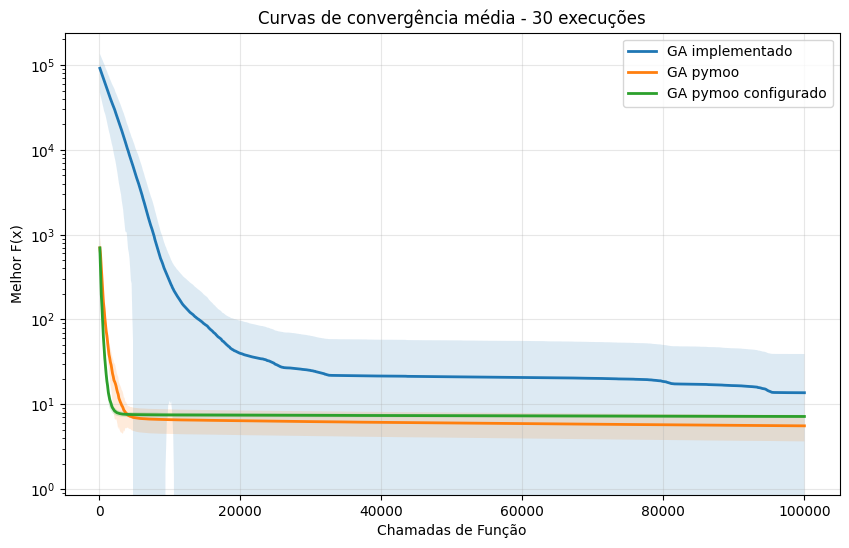

In [210]:
min_len = min(min(len(h) for h in historicos_manual_10d), min(len(h) for h in historicos_pymoo_10d), min(len(h) for h in historicos_pymoo_configurado_10d))

manual_array = np.array([h[:min_len] for h in historicos_manual_10d])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo_10d])
pymoo_configurado_array = np.array([h[:min_len] for h in historicos_pymoo_configurado_10d])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
media_pymoo_configurado = pymoo_configurado_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)
desvio_pymoo_configurado = pymoo_configurado_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.plot(eixo, media_pymoo_configurado, label="GA pymoo configurado", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.fill_between(eixo, media_pymoo_configurado - desvio_pymoo_configurado, media_pymoo_configurado + desvio_pymoo_configurado, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### Descrição da tabela

Dicionário textual da tabela:

- `Versão`: implementação avaliada no comparativo.
- `Fitness final médio`: média dos melhores fitness finais das 30 execuções.
- `Desvio padrão final`: variabilidade dos fitness finais entre as 30 execuções.
- `Mediana do fitness final`: valor mediano dos fitness finais.
- `Execução mediana`: execução mais próxima da mediana.
- `Fitness da execução mediana`: fitness final da execução mediana.

In [211]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo_2v = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual_10d),
    resumo_final_execucoes("GA pymoo", historicos_pymoo_10d),
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo_2v = tabela_resumo_2v[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo_2v)

melhor_media = tabela_resumo_2v.loc[tabela_resumo_2v["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo_2v.loc[tabela_resumo_2v["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)

Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,13.6985,25.5053,5.23377,16,5.24958
1,GA pymoo,5.57747,1.92067,6.05638,30,6.05737



Conclusão: Melhor média: GA pymoo, 
Melhor mediana: GA implementado.



### 10D (Implementado + pymoo padrão)

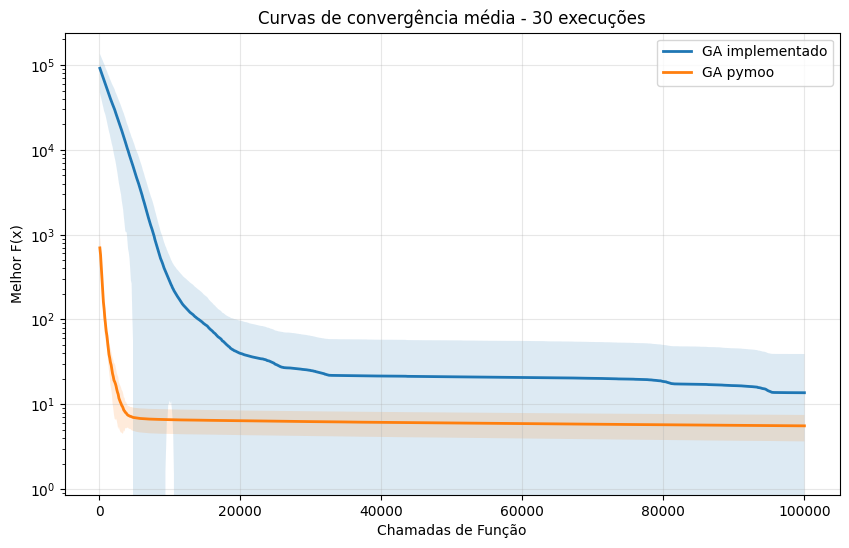

In [212]:
import matplotlib.pyplot as plt

min_len = min(min(len(h) for h in historicos_manual_10d), min(len(h) for h in historicos_pymoo_10d))

manual_array = np.array([h[:min_len] for h in historicos_manual_10d])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo_10d])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual_10d),
    resumo_final_execucoes("GA pymoo", historicos_pymoo_10d),
    resumo_final_execucoes("GA pymoo configurado", historicos_pymoo_configurado_10d),
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo = tabela_resumo[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo)

melhor_media = tabela_resumo.loc[tabela_resumo["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo.loc[tabela_resumo["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)


Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,13.6985,25.5053,5.23377,16,5.24958
1,GA pymoo,5.57747,1.92067,6.05638,30,6.05737
2,GA pymoo configurado,7.19376,0.281863,7.28029,21,7.27686



Conclusão: Melhor média: GA pymoo, 
Melhor mediana: GA implementado.



### 30D (Implementado + pymoo padrão + pymoo configurado)

In [214]:
n_execucoes = 30
dimensao = 30
num_individuos = 100
parada = 100000

In [215]:
import matplotlib.pyplot as plt

historicos_manual_30d = []
historicos_pymoo_configurado_30d = []
historicos_pymoo_30d = []

for execucao in range(n_execucoes):
    print(f"{execucao + 1}/{n_execucoes}")
    seed_execucao = SEED_BASE + execucao
    historicos_manual_30d.append(ga_manual(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo_30d.append(ga_pymoo(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))
    historicos_pymoo_configurado_30d.append(ga_pymoo_configurado(dimensao=dimensao, num_individuos=num_individuos, parada=parada, seed=seed_execucao))


1/30
2/30
3/30
4/30
5/30
6/30
7/30
8/30
9/30
10/30
11/30
12/30
13/30
14/30
15/30
16/30
17/30
18/30
19/30
20/30
21/30
22/30
23/30
24/30
25/30
26/30
27/30
28/30
29/30
30/30


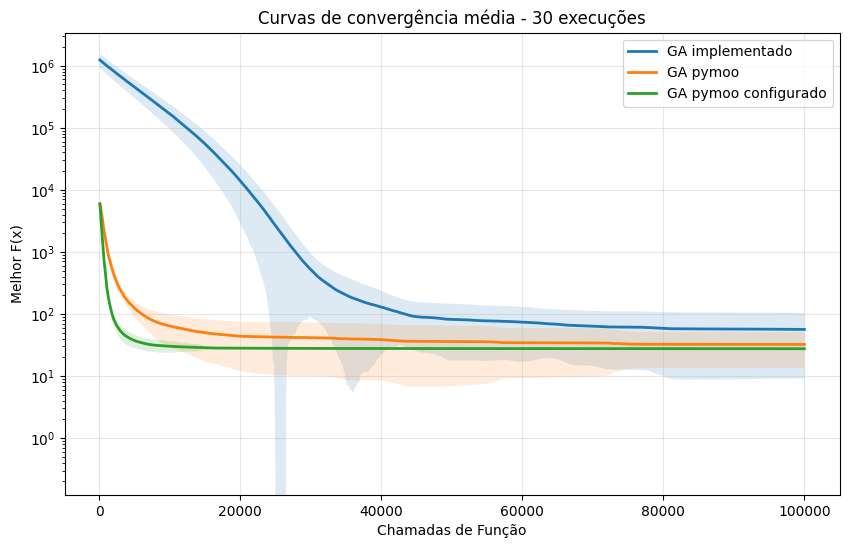

In [216]:
min_len = min(min(len(h) for h in historicos_manual_30d), min(len(h) for h in historicos_pymoo_30d), min(len(h) for h in historicos_pymoo_configurado_30d))

manual_array = np.array([h[:min_len] for h in historicos_manual_30d])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo_30d])
pymoo_configurado_array = np.array([h[:min_len] for h in historicos_pymoo_configurado_30d])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
media_pymoo_configurado = pymoo_configurado_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)
desvio_pymoo_configurado = pymoo_configurado_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.plot(eixo, media_pymoo_configurado, label="GA pymoo configurado", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.fill_between(eixo, media_pymoo_configurado - desvio_pymoo_configurado, media_pymoo_configurado + desvio_pymoo_configurado, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual_30d),
    resumo_final_execucoes("GA pymoo", historicos_pymoo_30d),
    resumo_final_execucoes("GA pymoo configurado", historicos_pymoo_configurado_30d),
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo = tabela_resumo[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo)

melhor_media = tabela_resumo.loc[tabela_resumo["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo.loc[tabela_resumo["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)


Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,56.3063,47.1505,26.7902,21,26.8206
1,GA pymoo,32.2322,18.6446,26.7791,23,26.7267
2,GA pymoo configurado,27.5255,0.567078,27.6556,5,27.663



Conclusão: Melhor média: GA pymoo configurado, 
Melhor mediana: GA pymoo.



### 30D (Implementado + pymoo padrão)

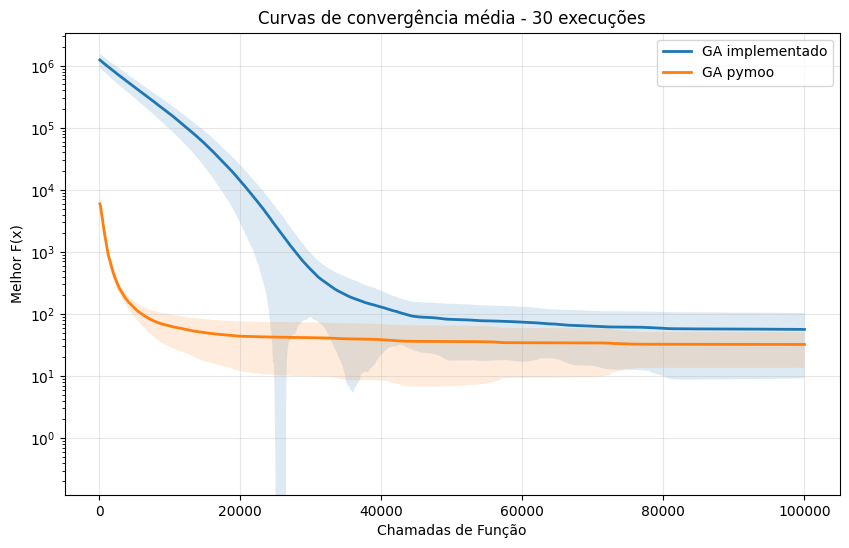

In [218]:
import matplotlib.pyplot as plt

min_len = min(min(len(h) for h in historicos_manual_30d), min(len(h) for h in historicos_pymoo_30d))

manual_array = np.array([h[:min_len] for h in historicos_manual_30d])
pymoo_array = np.array([h[:min_len] for h in historicos_pymoo_30d])

media_manual = manual_array.mean(axis=0)
media_pymoo = pymoo_array.mean(axis=0)
desvio_manual = manual_array.std(axis=0)
desvio_pymoo = pymoo_array.std(axis=0)

eixo = np.arange(1, min_len + 1) * num_individuos

plt.figure(figsize=(10, 6))
plt.plot(eixo, media_manual, label="GA implementado", linewidth=2)
plt.plot(eixo, media_pymoo, label="GA pymoo", linewidth=2)
plt.fill_between(eixo, media_manual - desvio_manual, media_manual + desvio_manual, alpha=0.15)
plt.fill_between(eixo, media_pymoo - desvio_pymoo, media_pymoo + desvio_pymoo, alpha=0.15)
plt.yscale("log")
plt.xlabel("Chamadas de Função")
plt.ylabel("Melhor F(x)")
plt.title("Curvas de convergência média - 30 execuções")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### Descrição da tabela

Dicionário textual da tabela:

- `Versão`: implementação avaliada no comparativo.
- `Fitness final médio`: média dos melhores fitness finais das 30 execuções.
- `Desvio padrão final`: variabilidade dos fitness finais entre as 30 execuções.
- `Mediana do fitness final`: valor mediano dos fitness finais.
- `Execução mediana`: execução mais próxima da mediana.
- `Fitness da execução mediana`: fitness final da execução mediana.

In [219]:
import numpy as np
import pandas as pd


def resumo_final_execucoes(nome, historicos):
    finais = np.array([float(h[-1]) for h in historicos], dtype=float)
    mediana = float(np.median(finais))
    idx_mediana = int(np.argmin(np.abs(finais - mediana)))

    return {
        "Versão": nome,
        "Fitness final médio": finais.mean(),
        "Desvio padrão final": finais.std(ddof=0),
        "Mediana do fitness final": mediana,
        "Execução mediana": idx_mediana + 1,
        "Fitness da execução mediana": finais[idx_mediana],
    }


tabela_resumo_2v = pd.DataFrame([
    resumo_final_execucoes("GA implementado", historicos_manual_30d),
    resumo_final_execucoes("GA pymoo", historicos_pymoo_30d),
])

ordem = [
    "Versão",
    "Fitness final médio",
    "Desvio padrão final",
    "Mediana do fitness final",
    "Execução mediana",
    "Fitness da execução mediana",
]

tabela_resumo_2v = tabela_resumo_2v[ordem]

pd.options.display.float_format = "{:.6g}".format
print("Resumo final das 30 execuções:")
display(tabela_resumo_2v)

melhor_media = tabela_resumo_2v.loc[tabela_resumo_2v["Fitness final médio"].idxmin(), "Versão"]
melhor_mediana = tabela_resumo_2v.loc[tabela_resumo_2v["Mediana do fitness final"].idxmin(), "Versão"]

print(
    f"\nConclusão: Melhor média: {melhor_media}, \n"
    f"Melhor mediana: {melhor_mediana}.\n"
)

Resumo final das 30 execuções:


,Versão,Fitness final médio,Desvio padrão final,Mediana do fitness final,Execução mediana,Fitness da execução mediana
0,GA implementado,56.3063,47.1505,26.7902,21,26.8206
1,GA pymoo,32.2322,18.6446,26.7791,23,26.7267



Conclusão: Melhor média: GA pymoo, 
Melhor mediana: GA pymoo.

